In [1]:
from os.path import curdir
from random import  random, sample, seed, randint, choice
from itertools import accumulate
import matplotlib.pyplot as plt
import numpy as np
from icecream import ic


In [2]:
def generate_universe(n: int, random_seed: int):
    seed(random_seed)
    universe = set(range(n))
    sets = list(set(sample(range(n), k=s+1)) for s in range(n))
    costs = list(10*random() + (s + random()) ** 2 for s in range(n))
    return universe, sets, costs

In [3]:
def fitness(solution: list[bool],
            universe: set[int],
            sets: list[set[int]],
            costs: list[float],
    ) -> float:
    """
    Calculates fitness function
    """
    n = len(solution)
    selected_sets = [sets[i] for i in range(n) if solution[i]]
    total_cost = sum(costs[i] for i in range(n) if solution[i])
    if not selected_sets:
        return - float("inf")
    elif set.union(*selected_sets) == universe:
        return - total_cost
    else:
        return - float("inf")


In [4]:
def tweak(solution: list[bool]) -> list[bool]:
    """
    Generates a neighbor by flipping one or more bits in a using random
    """
    new_sol = list(solution)
    while random() < 0.8:
        idx = randint(0, len(new_sol)-1)
        new_sol[idx] = not new_sol[idx]
    return new_sol


In [5]:
def hill_climbing(
        universe: set[int],
        sets_: list[set[int]],
        costs_: list[float],
        max_steps: int,
        init_solution: list[bool],
) -> tuple[float, list[bool] | None, list[float]]:
    n = len(universe)
    history = []
    current_sol = init_solution.copy()
    history.append(fitness(current_sol, universe, sets_, costs_))
    current_fit = fitness(current_sol, universe, sets_, costs_)
    for steps in range(max_steps):
        neighbor = tweak(current_sol)
        neighbor_fit = fitness(neighbor, universe, sets_, costs_)
        history.append(neighbor_fit)
        if neighbor_fit >= current_fit:
            current_fit = neighbor_fit
            current_sol = neighbor

    selected_sets = [sets[i] for i in range(n) if current_sol[i]]
    ic(max_steps, current_fit)
    print(len(selected_sets))
    return current_fit, current_sol, history

In [6]:
N = 100
universe, sets, costs = generate_universe(N, random_seed=0)
steps = 10_000


## All False Initial Solution

ic| max_steps: 10000, current_fit: -9951.153962669627


6


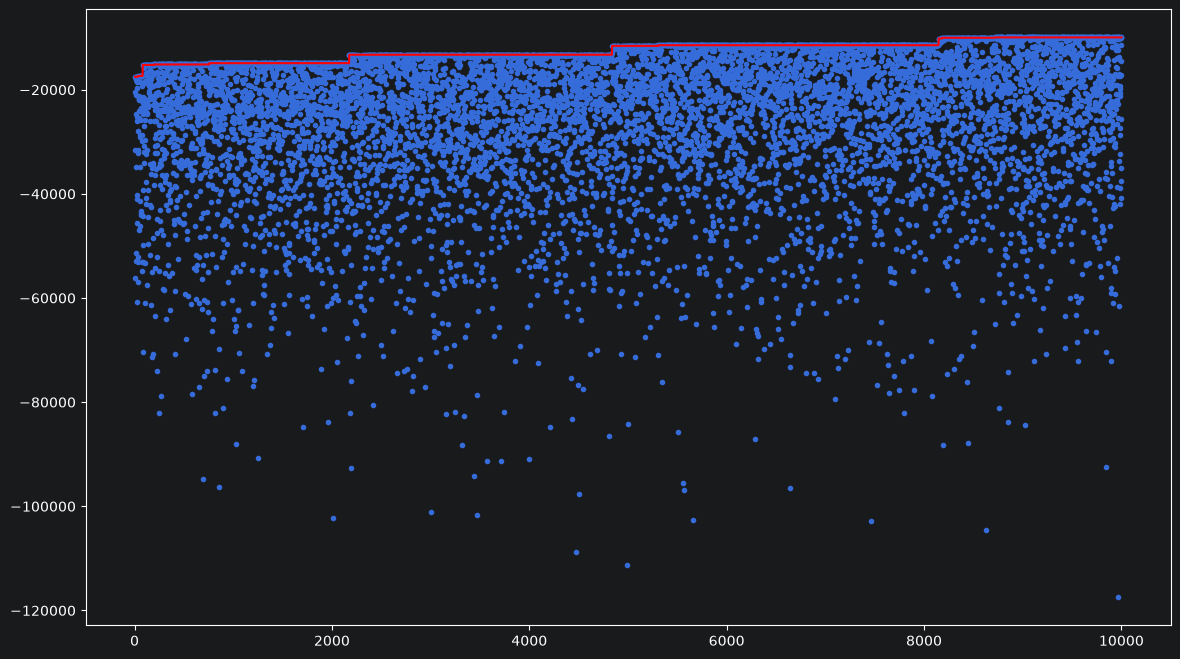

In [7]:
init_0_solution = [False] * N
_, _, history_0 = hill_climbing(universe, sets, costs, steps, init_0_solution)

plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history_0)),
    list(accumulate(history_0, max)),
    color='red'
)
# plt.ylim(np.sort(list(set(history_0)))[1], 0)
_ = plt.scatter(range(len(history_0)), history_0, marker='.')

## Random Initial Solution

ic| max_steps: 10000, current_fit: -7719.538137734142


8


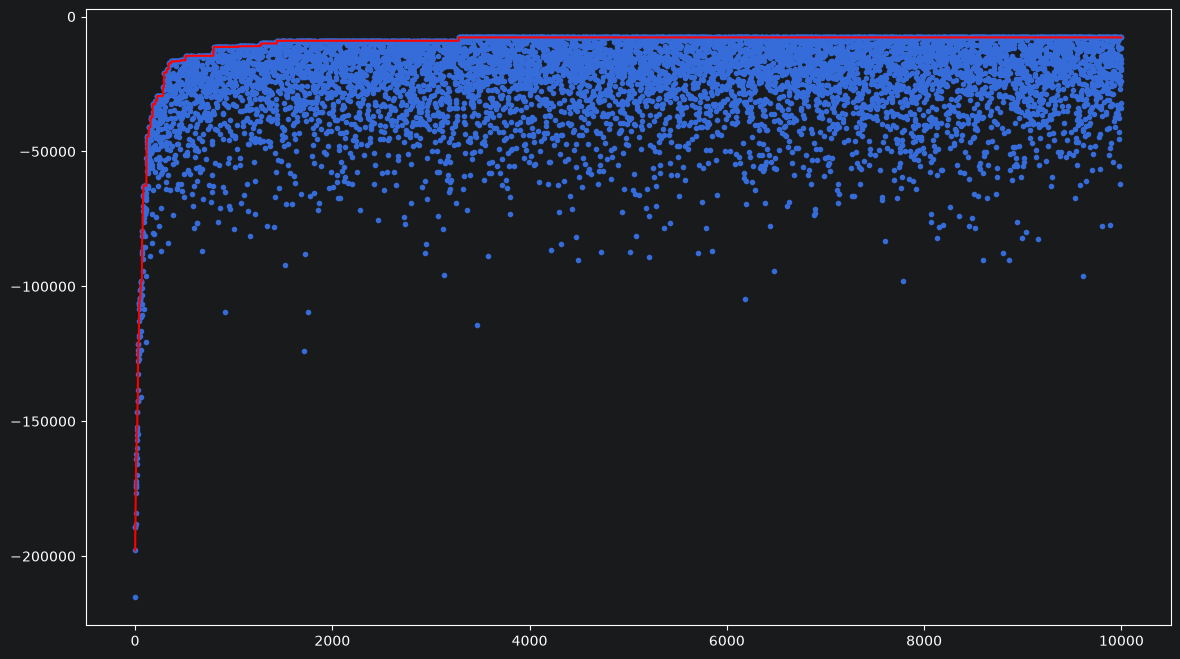

In [8]:
random_sol = list(sample([True, False], k=N, counts=(N, N))) # counts=(2, 2) --> sample([True, True , False, False], k=2)
_, _, history_rand = hill_climbing(universe, sets, costs, steps, random_sol)

plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history_rand)),
    list(accumulate(history_rand, max)),
    color='red'
)
# plt.ylim(np.sort(list(set(history_rand)))[1], 0)
_ = plt.scatter(range(len(history_rand)), history_rand, marker='.')


## All True Initial Solution

ic| max_steps: 10000, current_fit: -9162.715767812133


5


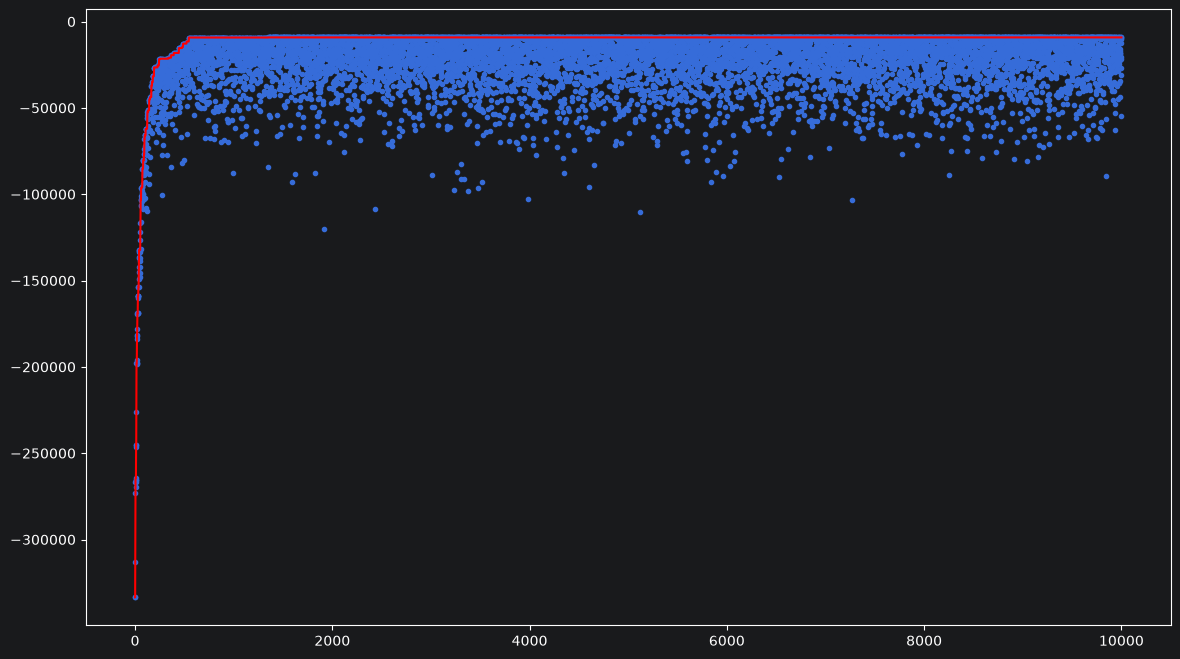

In [9]:
init_1_solution = [True] * N
_, _, history_1 = hill_climbing(universe, sets, costs, steps, init_1_solution)

plt.figure(figsize=(14, 8))
plt.plot(
    range(len(history_1)),
    list(accumulate(history_1, max)),
    color='red'
)
# plt.ylim(np.sort(list(set(history_1)))[1], 0)
_ = plt.scatter(range(len(history_1)), history_1, marker='.')
